# Tarea para el Hogar 05 — versión Python

Adaptación de `z494_python.ipynb` a la lógica de `z495_GustavoPasquini.ipynb`. La carga del dataset y la generación de la clase ternaria permanecen sin cambios.

# Librerías

In [1]:
import os
import cudf
import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd



from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
import optuna
from optuna.samplers import GPSampler
from optuna.trial import TrialState
from optuna.visualization import plot_param_importances, plot_contour,  plot_slice, plot_optimization_history




print('cuDF:', cudf.__version__)
print('GPU:', cp.cuda.runtime.getDeviceProperties(0)['name'].decode())



cuDF: 26.08.01
GPU: NVIDIA GeForce RTX 3090


In [2]:
import lightgbm as lgb
import yaml

In [3]:
# dispongo la carpeta con funciones e importo ternara. 
from pathlib import Path
import sys

# Obtiene la ruta del directorio actual y sube un nivel (.parent)
raiz_proyecto = Path().resolve().parent

# Agrega la ruta al sistema si no está ya incluida
if str(raiz_proyecto) not in sys.path:
  sys.path.append(str(raiz_proyecto))

# Importa tu librería o módulo
from funciones.ternaria import ternaria


# URLs

In [4]:
BASE_URL = os.path.join(
    os.path.expanduser("~"),
    "code", "DMEyF", "dmeyf2026"
)
BASE_DATA_URL = os.path.join('/mnt/', 'e')
DATA_FOLDER = os.path.join(BASE_DATA_URL, 'DATASETS', 'DMEyF')

DATA_URL = os.path.join(BASE_URL, "DATA")
DATASETS_URL = os.path.join(DATA_URL, "DATASETS")
EXP_URL = os.path.join(DATA_URL, "EXP")
dataset_url = os.path.join(DATASETS_URL, "competencia_01_crudo.csv")
DATA_TERNARIA_URL = os.path.join(DATA_FOLDER, 'competencia_01_ternaria.csv')
DATA_LAGS_URL = os.path.join(DATA_FOLDER, 'competencia_01_ternaria_lags.csv')
DATA_LAGS_FRAC_URL = os.path.join(DATA_FOLDER, 'competencia_01_ternaria_lf_k6_perdida4.csv')



experiment_name = "LAG-007-S"
EXPERIMENT_URL = os.path.join(EXP_URL, experiment_name)

os.makedirs(EXPERIMENT_URL, exist_ok=True)

In [5]:
os.listdir(DATA_FOLDER)

['competencia_01_crudo.csv',
 'competencia_01_ternaria.csv',
 'competencia_01_ternaria_lags.csv',
 'competencia_01_ternaria_lf_k6_perdida4.csv',
 'data_dict.csv',
 'DiccionarioDatos_2026.ods']

# Constantes

In [6]:
SEED = 230047

In [7]:
PARAM = {
    "experimento": experiment_name,
    "semilla_primigenia": SEED,
    "training_pct": 70,
    "train": [202103,202104],
    "train_final": [202103,202104],
    "future": [202106],
    "cortes": list(range(9_000, 15_001, 500)),
    "trainingstrategy": {"undersampling": 0.1},
    "hyperparametertuning": {
        "iteraciones": 100,
        "n_startup_trials": 30,
        "xval_folds" : 3
    },
    "lgbm": {
        "param_fijos": {
            "boosting": "gbdt",
            "objective": "binary",
            # "metric": "auc",
            "metric": "average_precision",
            "feature_pre_filter": False,
            "first_metric_only": False,
            "boost_from_average": True,
            "force_row_wise": True,
            "deterministic": True,
            "verbosity": -100,
            "seed": SEED,
            "max_depth": -1,
            "min_gain_to_split": 0.0,
            "lambda_l1": 0.0,
            "lambda_l2": 0.0,
            "max_bin": 31,
            "bagging_fraction": 1.0,
            "pos_bagging_fraction": 1.0,
            "neg_bagging_fraction": 1.0,
            "is_unbalance": False,
            "scale_pos_weight": 1.0,
            "drop_rate": 0.1,
            "max_drop": 50,
            "skip_drop": 0.5,
            "extra_trees": False,
            "early_stopping": 0,
            "min_data_in_leaf": 0,
            "feature_fraction": 0.50,
            # "learning_rate": 0.005,
  
        }
    },
    "out": {"lgbm": {}},
}


# Lectura del dataset

In [8]:
# cudf no pandas -> GPU
df = cudf.read_csv(
    DATA_LAGS_URL,
    dtype={'numero_de_cliente': 'int32', 'foto_mes': 'int32'}
)

In [9]:
df.head()

,numero_de_cliente,foto_mes,active_quarter,cliente_vip,internet,cliente_edad,cliente_antiguedad,mrentabilidad,mrentabilidad_annual,mcomisiones,...,Visa_madelantodolares_delta1,Visa_fultimo_cierre_delta1,Visa_mpagado_delta1,Visa_mpagospesos_delta1,Visa_mpagosdolares_delta1,Visa_fechaalta_delta1,Visa_mconsumototal_delta1,Visa_cconsumos_delta1,Visa_cadelantosefectivo_delta1,Visa_mpagominimo_delta1
0,12159854,202103,1,0,0,56,134,688.41,26701.84,98.82,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,12159854,202104,1,0,0,56,135,1622.57,27663.64,931.59,...,0.0,1.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0
2,12159854,202105,1,0,0,56,136,1987.98,28738.37,934.07,...,0.0,3.0,0.0,0.0,0.0,31.0,0.0,0.0,0.0,0.0
3,12159854,202106,1,0,0,56,137,2580.75,29494.76,915.19,...,0.0,-5.0,0.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0
4,12159854,202107,1,0,0,56,138,2686.85,29431.10,688.94,...,0.0,3.0,0.0,0.0,0.0,31.0,0.0,0.0,0.0,0.0


In [10]:
cudf.crosstab(df['ternaria'].fillna('NA'), df['foto_mes'])

foto_mes,202103,202104,202105,202106,202107,202108
ternaria,,,,,,
BAJA+1,1019,964,1143,874,1103,0
BAJA+2,960,1139,870,1098,0,0
NA,0,0,0,0,163245,164647
continua,160921,161181,161755,162142,0,0


In [11]:
df_completo = df.copy()

# Optimización de hiperparámetros

Se replica el presupuesto de z495: 10 evaluaciones totales. Como `mlr3mbo` usa por defecto un diseño inicial aleatorio de tamaño `4D` y aquí `D=3`, el presupuesto se agota durante la inicialización. En Optuna se reproduce con `n_startup_trials=10`, sin LHS explícito.

## Preprocesamiento

In [12]:
dataset_train_cpu = (
    df_completo
    .loc[df_completo["foto_mes"].isin(PARAM["train"])]
    .to_pandas()
    .reset_index(drop=True)
)

# Partición estratificada 70/30, equivalente a fold 1 y fold 2 en z495.
indices_fold_1, indices_fold_2 = train_test_split(
    np.arange(len(dataset_train_cpu)),
    train_size=PARAM["training_pct"] / 100,
    stratify=dataset_train_cpu["ternaria"],
    random_state=PARAM["semilla_primigenia"],
)

dataset_train_cpu["fold"] = np.int8(2)
dataset_train_cpu.loc[indices_fold_1, "fold"] = np.int8(1)

# BAJA+1 y BAJA+2 forman la clase positiva, igual que en el R.
dataset_train_cpu["clase01"] = (
    dataset_train_cpu["ternaria"].isin(["BAJA+1", "BAJA+2"])
    .astype(np.int8)
)

rng = np.random.default_rng(PARAM["semilla_primigenia"])
dataset_train_cpu["azar"] = rng.random(len(dataset_train_cpu))
dataset_train_cpu["training"] = (
    dataset_train_cpu["fold"].eq(1)
    & (
        (dataset_train_cpu["azar"] <= PARAM["trainingstrategy"]["undersampling"])
        | dataset_train_cpu["ternaria"].isin(["BAJA+1", "BAJA+2"])
    )
).astype(np.int8)

columnas_excluidas = {
    "ternaria",
    "ternaria_lag1",
    "clase01",
    "fold",
    "azar",
    "training",
    # "cprestamos_personales",
    # "cprestamos_personales_lag1",
    # "cprestamos_personales_delta1",
    # "mprestamos_personales",
    # "mprestamos_personales_lag1",
    # "mprestamos_personales_delta1"
}

campos_buenos = [
    columna
    for columna in dataset_train_cpu.columns
    if columna not in columnas_excluidas
]

mask_training = dataset_train_cpu["training"].eq(1)
X_train_bo = dataset_train_cpu.loc[mask_training, campos_buenos]
y_train_bo = dataset_train_cpu.loc[mask_training, "clase01"]

# Replica literalmente z495: validation contiene todas las filas con training == 0.
mask_validation = dataset_train_cpu["training"].eq(0)
X_validate_bo = dataset_train_cpu.loc[mask_validation, campos_buenos]
y_validate_bo = dataset_train_cpu.loc[mask_validation, "clase01"]

dtrain = lgb.Dataset(
    data=X_train_bo,
    label=y_train_bo,
    feature_name=campos_buenos,
    free_raw_data=False,
)

dvalidate = lgb.Dataset(
    data=X_validate_bo,
    label=y_validate_bo,
    feature_name=campos_buenos,
    free_raw_data=False,
)

print("Filas para training:", len(X_train_bo))
print("Filas para validation:", len(X_validate_bo))
print("Columnas:", len(campos_buenos))
dataset_train_cpu.groupby(["fold", "ternaria", "training"]).size()

Filas para training: 25373
Filas para validation: 300811
Columnas: 458


fold  ternaria  training
1     BAJA+1    1             1388
      BAJA+2    1             1469
      continua  0           202955
                1            22516
2     BAJA+1    0              595
      BAJA+2    0              630
      continua  0            96631
dtype: int64

## Función objetivo: Average Precision sobre validation

In [13]:
def estimar_auc_lightgbm(parametros_variables):
    parametros_completos = {
        **PARAM["lgbm"]["param_fijos"],
        **parametros_variables,
    }

    # En Python conviene pasar el número de árboles por su argumento dedicado.
    num_boost_round = int(parametros_completos.pop("num_iterations"))

    resultados_cv = lgb.cv(
        params=parametros_completos,
        train_set=dtrain,
        num_boost_round=num_boost_round,
        nfold=PARAM["hyperparametertuning"]["xval_folds"],
        stratified=True,
        shuffle=True,
        seed=PARAM["semilla_primigenia"],
    )

    clave_auc = next(
        clave for clave in resultados_cv
        if clave.endswith("auc-mean")
    )

    # Sin early stopping, equivale al score al finalizar num_iterations.
    return float(resultados_cv[clave_auc][-1])

In [14]:
def estimar_ap_lightgbm(parametros_variables):
    parametros_completos = {
        **PARAM["lgbm"]["param_fijos"],
        **parametros_variables,
    }

    num_boost_round = int(parametros_completos.pop("num_iterations"))

    modelo = lgb.train(
        params=parametros_completos,
        train_set=dtrain,
        num_boost_round=num_boost_round,
        valid_sets=[dvalidate],
        valid_names=["val"],
    )

    return float(modelo.best_score["val"]["average_precision"])

In [15]:
ganancia_validate_bo = np.where(
    dataset_train_cpu.loc[mask_validation, "ternaria"].eq("BAJA+2"),
    1_072_500,
    -27_500,
)


def estimar_ganancia_lightgbm(parametros_variables):
    parametros_completos = {
        **PARAM["lgbm"]["param_fijos"],
        **parametros_variables,
    }

    num_boost_round = int(
        parametros_completos.pop("num_iterations")
    )

    modelo = lgb.train(
        params=parametros_completos,
        train_set=dtrain,
        num_boost_round=num_boost_round,
    )

    prediccion = modelo.predict(X_validate_bo)
    orden = np.argsort(-prediccion)

    ganancia_acumulada = np.cumsum(
        ganancia_validate_bo[orden]
    )

    return float(ganancia_acumulada.max())

In [16]:
def objective(trial):
    parametros_variables = {
        "num_iterations": trial.suggest_int("num_iterations", 64, 3500),
        "num_leaves": trial.suggest_int("num_leaves", 16, 2048),
        "feature_fraction": trial.suggest_float("feature_fraction",  0.30,  0.70),
        "min_sum_hessian_in_leaf": trial.suggest_float(
            "min_sum_hessian_in_leaf", 0.0001, 0.1
        ),
        "learning_rate": trial.suggest_float("learning_rate", 0.002, 0.02),
    }
    return estimar_ap_lightgbm(parametros_variables)
    # return estimar_auc_lightgbm(parametros_variables)
    # return estimar_ganancia_lightgbm(parametros_variables)

## Estudio Optuna y reanudación

In [17]:
n_startup_trials = PARAM["hyperparametertuning"]["n_startup_trials"]
n_trials_total = PARAM["hyperparametertuning"]["iteraciones"]

sampler = GPSampler(
    seed=PARAM["semilla_primigenia"],
    n_startup_trials=n_startup_trials,
    deterministic_objective=False,
)

study_db_url = os.path.join(EXPERIMENT_URL, "optuna_study.db")
storage_url = f"sqlite:///{study_db_url}"

study = optuna.create_study(
    study_name=experiment_name,
    direction="maximize",
    sampler=sampler,
    storage=storage_url,
    load_if_exists=True,
)

/tmp/ipykernel_295712/1912430851.py:4: ExperimentalWarning: GPSampler is experimental (supported from v3.6.0). The interface can change in the future.
  sampler = GPSampler(
[I 2026-09-23 10:12:16,606] A new study created in RDB with name: LAG-007-S


In [18]:
trials_completos = sum(
    trial.state == TrialState.COMPLETE
    for trial in study.trials
)
trials_restantes = max(0, n_trials_total - trials_completos)

print("Trials completos:", trials_completos)
print("Trials restantes:", trials_restantes)

if trials_restantes > 0:
    study.optimize(
        objective,
        n_trials=trials_restantes,
        show_progress_bar=True,
    )
else:
    print("c'est fini")

Trials completos: 0
Trials restantes: 100


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-09-23 10:12:48,755] Trial 0 finished with value: 0.12349929838589903 and parameters: {'num_iterations': 382, 'num_leaves': 940, 'feature_fraction': 0.5729133654827125, 'min_sum_hessian_in_leaf': 0.00553916868998496, 'learning_rate': 0.015900459123825674}. Best is trial 0 with value: 0.12349929838589903.
[I 2026-09-23 10:13:28,536] Trial 1 finished with value: 0.14918124524892035 and parameters: {'num_iterations': 2204, 'num_leaves': 107, 'feature_fraction': 0.583693910172127, 'min_sum_hessian_in_leaf': 0.06261189341024793, 'learning_rate': 0.01870930910473581}. Best is trial 1 with value: 0.14918124524892035.
[I 2026-09-23 10:14:28,648] Trial 2 finished with value: 0.13500947759558451 and parameters: {'num_iterations': 1740, 'num_leaves': 1193, 'feature_fraction': 0.4841347665370339, 'min_sum_hessian_in_leaf': 0.025985724915563353, 'learning_rate': 0.016012321156169476}. Best is trial 1 with value: 0.14918124524892035.
[I 2026-09-23 10:15:56,050] Trial 3 finished with value: 0.

## Resultados de la optimización

In [19]:
tb_bayesiana = study.trials_dataframe()
tb_bayesiana["iter"] = np.arange(1, len(tb_bayesiana) + 1)
tb_bayesiana = (
    tb_bayesiana
    .sort_values("value", ascending=False, na_position="last")
    .reset_index(drop=True)
)
tb_bayesiana.to_csv(
    os.path.join(EXPERIMENT_URL, "BO_log.txt"),
    sep="	",
    index=False,
)

PARAM["out"]["lgbm"]["mejores_hiperparametros"] = dict(study.best_trial.params)
PARAM["out"]["lgbm"]["y"] = float(study.best_value)

with open(os.path.join(EXPERIMENT_URL, "PARAM.yml"), "w", encoding="utf-8") as archivo:
    yaml.safe_dump(PARAM, archivo, sort_keys=False, allow_unicode=True)

print(PARAM["out"]["lgbm"]["mejores_hiperparametros"])
print("Mejor Average Precision:", PARAM["out"]["lgbm"]["y"])
tb_bayesiana.head()

{'num_iterations': 2140, 'num_leaves': 133, 'feature_fraction': 0.5360308906391008, 'min_sum_hessian_in_leaf': 0.0001, 'learning_rate': 0.02}
Mejor Average Precision: 0.15248491144081028


,number,value,datetime_start,datetime_complete,duration,params_feature_fraction,params_learning_rate,params_min_sum_hessian_in_leaf,params_num_iterations,params_num_leaves,system_attrs_gp:relative_params:0,state,iter
0,65,0.152485,2026-09-23 11:10:08.820409,2026-09-23 11:10:47.696352,0 days 00:00:38.875943,0.536031,0.02,0.0001,2140,133,"{""feature_fraction"": 0.5360308906391008, ""lear...",COMPLETE,66
1,96,0.151856,2026-09-23 11:38:06.405506,2026-09-23 11:38:47.503934,0 days 00:00:41.098428,0.493442,0.02,0.0001,2320,133,"{""feature_fraction"": 0.493441964048029, ""learn...",COMPLETE,97
2,98,0.151674,2026-09-23 11:39:37.519189,2026-09-23 11:40:18.659186,0 days 00:00:41.139997,0.497791,0.02,0.0001,2319,133,"{""feature_fraction"": 0.4977907027041363, ""lear...",COMPLETE,99
3,80,0.151232,2026-09-23 11:25:13.224076,2026-09-23 11:25:58.113752,0 days 00:00:44.889676,0.486346,0.02,0.0001,2462,143,"{""feature_fraction"": 0.48634643005698264, ""lea...",COMPLETE,81
4,48,0.151154,2026-09-23 10:57:59.381310,2026-09-23 10:58:30.430937,0 days 00:00:31.049627,0.458533,0.02,0.0001,1646,161,"{""feature_fraction"": 0.4585330756367768, ""lear...",COMPLETE,49


In [20]:
plot_optimization_history(study)

In [21]:
plot_slice(study)

In [22]:
plot_contour(study)

# Producción

## Final training sobre todos los datos de 202104

In [23]:
dataset_final_cpu = (
    df_completo
    .loc[df_completo["foto_mes"].isin(PARAM["train_final"])]
    .to_pandas()
    .reset_index(drop=True)
)
dataset_final_cpu["clase01"] = (
    dataset_final_cpu["ternaria"].isin(["BAJA+1", "BAJA+2"])
    .astype(np.int8)
)

dataset_final_cpu.groupby("ternaria").size()

ternaria
BAJA+1        1983
BAJA+2        2099
continua    322102
dtype: int64

In [24]:
dataset_final_cpu.clase01.value_counts()

clase01
0    322102
1      4082
Name: count, dtype: int64

In [25]:
param_final = {
    **PARAM["lgbm"]["param_fijos"],
    **PARAM["out"]["lgbm"]["mejores_hiperparametros"],
}

num_boost_round_final = int(param_final.pop("num_iterations"))
param_final

{'boosting': 'gbdt',
 'objective': 'binary',
 'metric': 'average_precision',
 'feature_pre_filter': False,
 'first_metric_only': False,
 'boost_from_average': True,
 'force_row_wise': True,
 'deterministic': True,
 'verbosity': -100,
 'seed': 230047,
 'max_depth': -1,
 'min_gain_to_split': 0.0,
 'lambda_l1': 0.0,
 'lambda_l2': 0.0,
 'max_bin': 31,
 'bagging_fraction': 1.0,
 'pos_bagging_fraction': 1.0,
 'neg_bagging_fraction': 1.0,
 'is_unbalance': False,
 'scale_pos_weight': 1.0,
 'drop_rate': 0.1,
 'max_drop': 50,
 'skip_drop': 0.5,
 'extra_trees': False,
 'early_stopping': 0,
 'min_data_in_leaf': 0,
 'feature_fraction': 0.5360308906391008,
 'num_leaves': 133,
 'min_sum_hessian_in_leaf': 0.0001,
 'learning_rate': 0.02}

In [26]:
print(campos_buenos)

['numero_de_cliente', 'foto_mes', 'active_quarter', 'cliente_vip', 'internet', 'cliente_edad', 'cliente_antiguedad', 'mrentabilidad', 'mrentabilidad_annual', 'mcomisiones', 'mactivos_margen', 'mpasivos_margen', 'cproductos', 'tcuentas', 'ccuenta_corriente', 'mcuenta_corriente_adicional', 'mcuenta_corriente', 'ccaja_ahorro', 'mcaja_ahorro', 'mcaja_ahorro_adicional', 'mcaja_ahorro_dolares', 'cdescubierto_preacordado', 'mcuentas_saldo', 'ctarjeta_debito', 'ctarjeta_debito_transacciones', 'mautoservicio', 'ctarjeta_visa', 'ctarjeta_visa_transacciones', 'mtarjeta_visa_consumo', 'ctarjeta_master', 'ctarjeta_master_transacciones', 'mtarjeta_master_consumo', 'cprestamos_personales', 'mprestamos_personales', 'cprestamos_prendarios', 'mprestamos_prendarios', 'cprestamos_hipotecarios', 'mprestamos_hipotecarios', 'cplazo_fijo', 'mplazo_fijo_dolares', 'mplazo_fijo_pesos', 'cinversion1', 'minversion1_pesos', 'minversion1_dolares', 'cinversion2', 'minversion2', 'cseguro_vida', 'cseguro_auto', 'csegur

In [27]:
dtrain_final = lgb.Dataset(
    data=dataset_final_cpu[campos_buenos],
    label=dataset_final_cpu["clase01"],
    feature_name=campos_buenos,
)

modelo_final = lgb.train(
    params=param_final,
    train_set=dtrain_final,
    num_boost_round=num_boost_round_final,
)

## Importancia de variables y modelo

In [28]:
arboles_df = modelo_final.trees_to_dataframe()
splits_df = arboles_df.loc[arboles_df["split_feature"].notna()]

tb_importancia = (
    splits_df
    .groupby("split_feature", as_index=False)
    .agg(
        Gain=("split_gain", "sum"),
        Cover=("count", "sum"),
        Frequency=("split_feature", "size"),
    )
    .rename(columns={"split_feature": "Feature"})
)

for columna in ["Gain", "Cover", "Frequency"]:
    total = tb_importancia[columna].sum()
    if total > 0:
        tb_importancia[columna] = tb_importancia[columna] / total

tb_importancia = tb_importancia.sort_values("Gain", ascending=False)
tb_importancia.to_csv(
    os.path.join(EXPERIMENT_URL, "impo.txt"),
    sep="\t",
    index=False,
)
modelo_final.save_model(os.path.join(EXPERIMENT_URL, "modelo.txt"))

tb_importancia.head(20)

,Feature,Gain,Cover,Frequency
291,ctrx_quarter,0.079312,0.011420,0.013983
310,mcaja_ahorro,0.037617,0.010582,0.013013
375,mpasivos_margen,0.031332,0.007204,0.014861
378,mpayroll,0.028954,0.008437,0.002630
392,mprestamos_personales,0.025091,0.015969,0.006227
349,mcuentas_saldo,0.024589,0.017243,0.017640
225,cpayroll_trx,0.024243,0.007220,0.001933
209,cliente_edad,0.022930,0.016063,0.032484
399,mrentabilidad_annual,0.022911,0.029616,0.027078
341,mcuenta_corriente,0.022175,0.013049,0.022472


## Scoring sobre 202106

In [29]:
df_completo.shape

(983061, 460)

In [30]:
dfuture_cpu = (
    df_completo
    .loc[df_completo["foto_mes"].isin(PARAM["future"])]
    .to_pandas()
    .reset_index(drop=True)
)

prediccion = modelo_final.predict(dfuture_cpu[campos_buenos])

tb_prediccion = dfuture_cpu[["numero_de_cliente", "foto_mes", "ternaria"]].copy()
tb_prediccion["prob"] = prediccion
tb_prediccion[["numero_de_cliente", "foto_mes", "prob"]].to_csv(
    os.path.join(EXPERIMENT_URL, "prediccion.txt"),
    sep="\t",
    index=False,
)

tb_prediccion.head()

,numero_de_cliente,foto_mes,ternaria,prob
0,12159854,202106,continua,0.000017
1,12159858,202106,continua,0.000054
2,12160484,202106,continua,0.000052
3,12160591,202106,continua,0.000004
4,12160747,202106,continua,0.000605


## Curva de ganancia

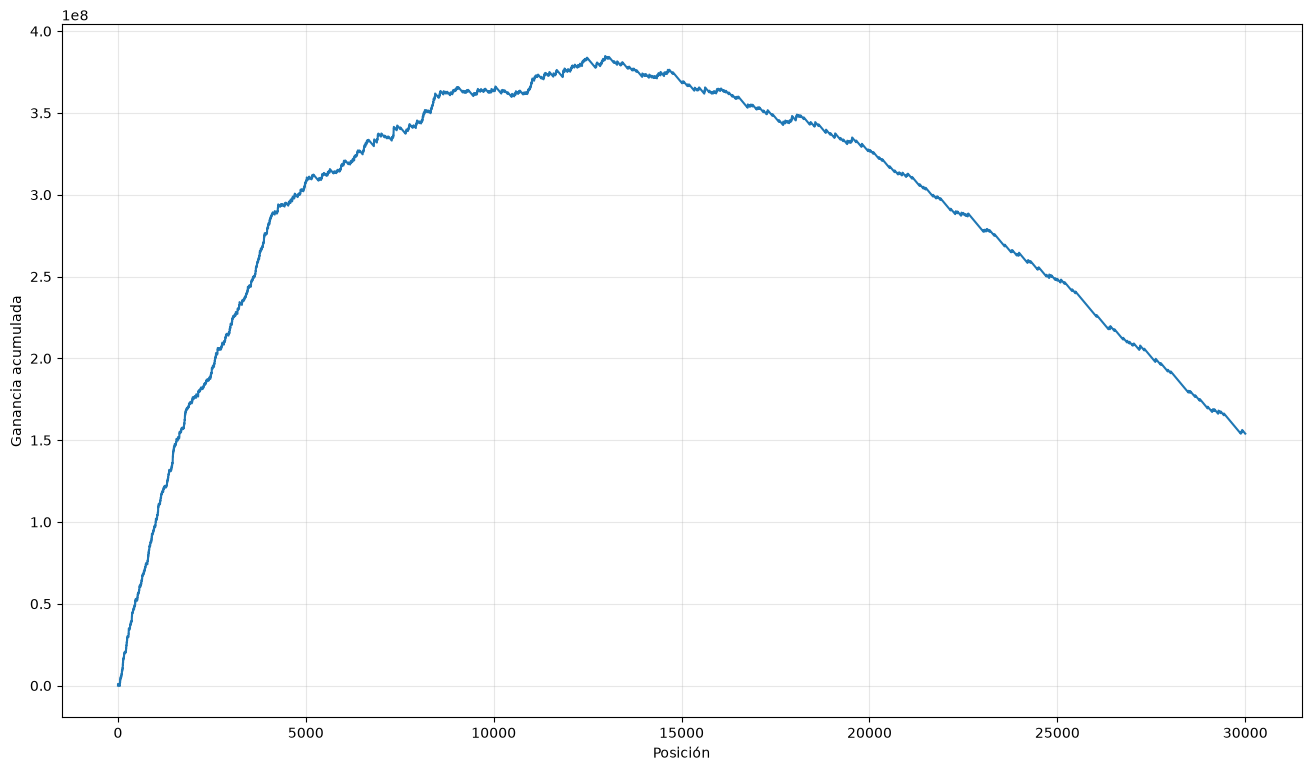

In [31]:
tb_prediccion = tb_prediccion.sort_values("prob", ascending=False).reset_index(drop=True)
tb_prediccion["gan"] = np.where(
    tb_prediccion["ternaria"].eq("BAJA+2"),
    1_072_500,
    -27_500,
)
tb_prediccion["ganancia_acumulada"] = tb_prediccion["gan"].cumsum()
tb_prediccion["pos"] = np.arange(1, len(tb_prediccion) + 1)

amostrar = 30_000
datos_plot = tb_prediccion.loc[tb_prediccion["pos"] <= amostrar]

plt.figure(figsize=(16, 9))
plt.plot(datos_plot["pos"], datos_plot["ganancia_acumulada"])
plt.xlabel("Posición")
plt.ylabel("Ganancia acumulada")
plt.grid(alpha=0.3)
plt.show()

## Ganancia bajo distintos cortes

In [32]:
resultados_cortes = []

for envios in PARAM["cortes"]:
    ganancia = tb_prediccion.iloc[:envios]["gan"].sum()
    resultados_cortes.append({
        "envios": envios,
        "ganancia": ganancia,
    })
    print(f"{envios}	{ganancia:.0f}")

resultados_cortes_df = pd.DataFrame(resultados_cortes)
resultados_cortes_df

9000	364100000
9500	361350000
10000	364100000
10500	361350000
11000	368500000
11500	374550000
12000	376200000
12500	383350000
13000	383900000
13500	378950000
14000	372900000
14500	373450000
15000	368500000


,envios,ganancia
0,9000,364100000
1,9500,361350000
2,10000,364100000
3,10500,361350000
4,11000,368500000
5,11500,374550000
6,12000,376200000
7,12500,383350000
8,13000,383900000
9,13500,378950000


In [33]:
with open(os.path.join(EXPERIMENT_URL, "PARAM.yml"), "w", encoding="utf-8") as archivo:
    yaml.safe_dump(PARAM, archivo, sort_keys=False, allow_unicode=True)